In [ ]:
from zipfile import ZipFile
from tqdm.auto import tqdm
import os

def unzip_resume(zip_path, dest):
    os.makedirs(dest, exist_ok=True)

    with ZipFile(zip_path) as z:
        members = z.infolist()

        for info in tqdm(members, unit="file", desc="Extracting"):
            if info.is_dir():
                continue

            out_path = os.path.join(dest, info.filename)

            # Skip if already extracted
            if os.path.exists(out_path):
                continue

            # Ensure parent directories exist
            os.makedirs(os.path.dirname(out_path), exist_ok=True)

            z.extract(info, dest)

unzip_resume(
    "/Volumes/Transcend/trancamento_candidates_e_corpus.zip",
    "/Volumes/Transcend/trancamento_candidates_e_corpus"
)

Extracting:   0%|          | 0/533481 [00:00<?, ?file/s]

In [4]:
import tgt, glob

In [7]:
tgrd_fs = glob.glob("it_vxc_textgrids17_acoustic17/*")

In [9]:
tgrd = tgt.read_textgrid(tgrd_fs[0])

In [17]:
import fasttext

model = fasttext.load_model("lid.176.bin")

sentence = " ".join([interval.text for interval in tgrd.tiers[0]])

tokens = sentence.split()

print(sentence)
print()
for tok in tokens:
    label, prob = model.predict(tok)
    prob = prob[0]
    print(tok, label, prob)

è nota al grande pubblico principalmente per la sua interpretazione di livia in roma

è ('__label__it',) 1.000040054321289
nota ('__label__it',) 0.318013072013855
al ('__label__es',) 0.5781728029251099
grande ('__label__it',) 0.4599470794200897
pubblico ('__label__it',) 1.0
principalmente ('__label__it',) 0.6736652255058289
per ('__label__it',) 0.9881653785705566
la ('__label__eo',) 0.8440331220626831
sua ('__label__pt',) 0.8834720253944397
interpretazione ('__label__it',) 0.9979903697967529
di ('__label__it',) 1.0000386238098145
livia ('__label__en',) 0.2112095057964325
in ('__label__en',) 0.9996092319488525
roma ('__label__it',) 0.2660057842731476


In [21]:
import fasttext

model = fasttext.load_model("lid.176.bin")

sent = "è nota al grande pubblico principally by the sua interpretazione di livia in roma"

labels, probs = model.predict(sent, k=5)  # top-5 languages
top = labels[0].replace("__label__", "")
top_p = float(probs[0])

print("Top:", top, top_p)

# probability assigned to Italian if it appears in the top-k
p_it = 0.0
for lab, p in zip(labels, probs):
    if lab == "__label__it":
        p_it = float(p)
        break

print("P(it) in top-5:", p_it)


Top: it 0.9983967542648315
P(it) in top-5: 0.9983967542648315


In [19]:
labels, probs

(('__label__it', '__label__ca', '__label__eu', '__label__pt', '__label__en'),
 array([9.99224365e-01, 1.44538484e-04, 1.28326385e-04, 7.63548669e-05,
        7.61251868e-05]))

In [1]:
import pandas as pd
import datetime

In [7]:
df = pd.read_csv("gold_labels.csv")

In [8]:
df

,word,unique_id,label
0,Mostrare,17415771_e_2.16_2.29,1.0
1,firmare,17415773_e_1.9_2.01,1.0
2,come,17415773_e_2.19_2.26,1.0
3,come,17415774_e_4.82_4.88,1.0
4,fine,17415780_e_0.64_0.69,1.0
...,...,...,...
901,parlare,30141438_<dummye>_2.88_2.89,1.0
902,scrivere,20254483_<dummye>_4.03_4.04,1.0
903,padre,20055947_<dummye>_1.53_1.54,-1.0
904,scopre,21190798_<dummye>_2.48_2.49,-1.0


In [12]:
df[df["word"]=="le"].reset_index(drop=True).to_csv("gold_labels_leonly.csv")

In [2]:
df_tm = pd.concat([
    pd.read_csv("/Users/pohsuan/Downloads/往來明細-1.csv"),
    pd.read_csv("/Users/pohsuan/Downloads/往來明細-2.csv"),
    pd.read_csv("/Users/pohsuan/Downloads/往來明細-3.csv")
    ])
df_tm["time"] = pd.to_datetime(df_tm["交易日"])
df_tm = df_tm[df_tm["time"]>=datetime.datetime(2025, 8, 27)]

df_us = pd.concat([
    pd.read_csv("/Users/pohsuan/Downloads/往來明細-4.csv"),
    pd.read_csv("/Users/pohsuan/Downloads/往來明細-5.csv"),
    ])
df_us["time"] = pd.to_datetime(df_us["交易日"])
df_us = df_us[df_us["time"]>=datetime.datetime(2025, 8, 27)]

In [3]:
def update_balance(action, amount, time, account_type):
    global starting_balance_tm, starting_balance_us, starting_balance_stock_tm, starting_balance_stock_us
    data["time"]+=[time]
    if action in ['\t大戶回饋', "\t手機換匯", "\t海外股息", "\t國外股息", "\t簽帳卡", "\t利息存入", "\t折讓款", "\t永豐卡費", "\tACH股息", "\t跨行轉帳"]:
        previous_amount = data[f"balance_{account_type}"][-1]
        data[f"balance_{account_type}"]+=[previous_amount + amount]
        for k in data:
            if k not in [f"balance_{account_type}", "time"]:
                previous_amount = data[k][-1]
                data[k]+=[previous_amount]
    elif action in ["\t股票款", "\t定期買股", "\t申購預扣", "\t申購退還", "\t股款交割"]:
        previous_amount = data[f"balance_{account_type}"][-1]
        data[f"balance_{account_type}"]+=[previous_amount + amount]
        previous_stock_amount = data[f"stock_balance_{account_type}"][-1]
        data[f"stock_balance_{account_type}"]+=[previous_stock_amount - amount]
        for k in data:
            if k not in [f"balance_{account_type}", f"stock_balance_{account_type}", "time"]:
                previous_amount = data[k][-1]
                data[k]+=[previous_amount]
    else: raise NotImplementedError(f"Unknown action: {action}")

In [4]:
starting_time = min(df_tm["time"].min(), df_us["time"].min())
starting_balance_tm = df_tm[" 餘額"].values[0]
starting_balance_us = 2.87
starting_balance_stock_tm = 0
starting_balance_stock_us = 0

rate = 31

data = {
    "time": [starting_time],
    "balance_tm": [starting_balance_tm],
    "balance_us": [starting_balance_us],
    "stock_balance_tm": [starting_balance_stock_tm],
    "stock_balance_us": [starting_balance_stock_us]
}
df_tm["type"] = "tm"
df_us["type"] = "us"
combined_df = pd.concat([df_tm, df_us])
combined_df.sort_values(by="time")
for _, row in combined_df.iterrows():
    try:
        expense = float(row[" 支出"])
    except ValueError:
        expense = 0
    try:
        income = float(row[" 存入"])
    except ValueError:
        income = 0
    amount = income - expense
    update_balance(row[" 摘要"], amount, row["time"], row["type"])
for k in data:
    if k.endswith("us"):
        data[k] = [x * rate for x in data[k]]

In [5]:
plot_data = pd.DataFrame(data)

In [6]:
plot_data.drop_duplicates(subset=["time"], keep="last", inplace=True)

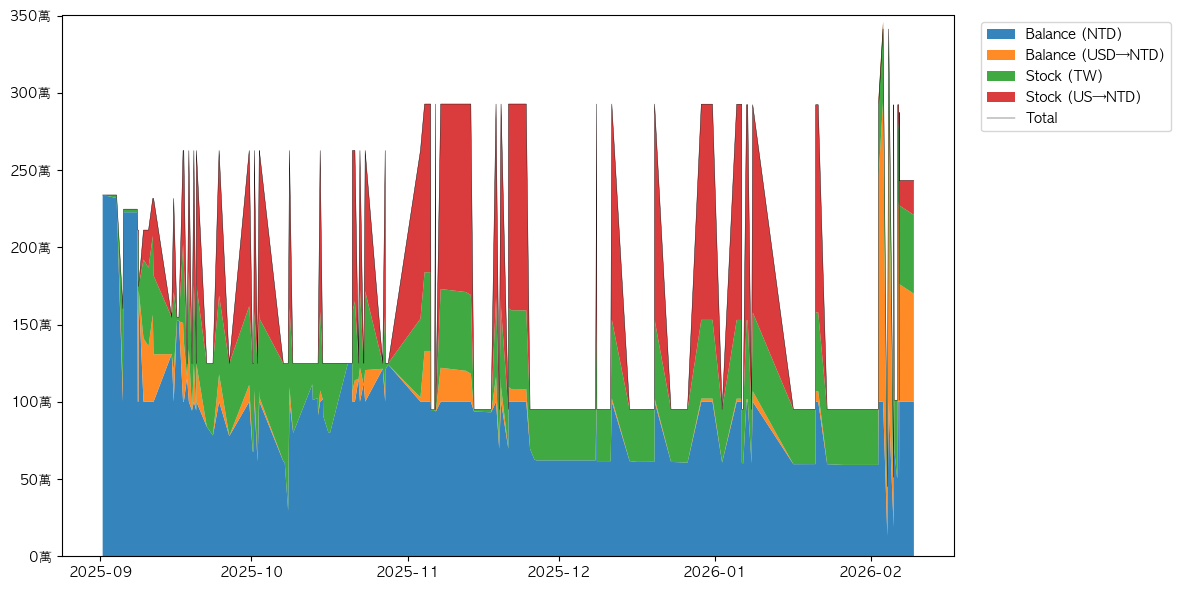

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"

# ---- 0) ensure time is datetime + sorted
plot_data = plot_data.copy()
plot_data["time"] = pd.to_datetime(plot_data["time"])
plot_data = plot_data.sort_values("time")

plot_data["balance_us"] = plot_data["balance_us"]
plot_data["stock_balance_us"] = plot_data["stock_balance_us"]
# plot_data = plot_data[plot_data["time"]>=pd.to_datetime("2025-11-01")]

# ---- 2) Build the components (all in NTD)
parts = pd.DataFrame({
    "Balance (NTD)": plot_data["balance_tm"].values,
    "Balance (USD→NTD)": plot_data["balance_us"].values,
    "Stock (TW)": plot_data["stock_balance_tm"].values,
    "Stock (US→NTD)": plot_data["stock_balance_us"].values,
}, index=plot_data["time"])

# (optional) if you have irregular dates, smooth to daily so the area looks nicer:
# parts = parts.resample("D").ffill()

total = parts.sum(axis=1)

# ---- 3) Plot stacked + total
fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(parts.index, parts.T.values, labels=parts.columns, alpha=0.9)
ax.plot(parts.index, total.values, label="Total", linewidth=.3, color="black")

ax.set_ylabel("")
ax.set_xlabel("")
ax.set_ylim(0, 3500000)
ax.set_yticks(range(0, 3500001, 500000))
ax.set_yticklabels([f"{i//10000}萬" for i in range(0, 3500001, 500000)])

ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()


In [8]:
parts["total"] = parts.sum(axis=1)
parts

,Balance (NTD),Balance (USD→NTD),Stock (TW),Stock (US→NTD),total
time,,,,,
2025-09-01 10:42:00,2338280.0,88.97,0.0,0.00,2338368.97
2025-09-04 05:08:00,2318402.0,88.97,19878.0,0.00,2338368.97
2025-09-05 11:08:00,1000498.0,93088.97,509683.0,0.00,1603269.97
2025-09-05 14:23:00,2226722.0,88.97,19878.0,0.00,2246688.97
2025-09-08 07:40:00,2226731.0,88.97,19878.0,0.00,2246697.97
...,...,...,...,...,...
2026-02-06 13:09:00,1000498.0,1250762.89,509683.0,161328.34,2922272.23
2026-02-06 14:52:00,500499.0,88.97,509683.0,0.00,1010270.97
2026-02-06 15:13:00,1000498.0,1201776.69,509683.0,161328.34,2873286.03
